In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Results

In [32]:
def create_method_colors(df: pd.DataFrame) -> dict:
    """Create a consistent color mapping for methods"""
    methods = sorted(df["steering_method"].unique())
    colors = sns.color_palette("deep", n_colors=len(methods))
    return dict(zip(methods, colors))

In [33]:
def plot_ridgeline_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    save_path: str = None,
):
    """
    Create ridgeline plots (one per metric) comparing score distributions across methods.
    """
    method_colors = create_method_colors(df)

    fig, axes = plt.subplots(
        len(metrics), 1, figsize=(8, 3 * len(metrics)), sharex=True
    )
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        plot_ridgeline_metric(
            df,
            metric,
            ax,
            methods,
            method_colors,
        )
        ax.set_title(metric.capitalize(), fontsize=14)

    axes[-1].set_xlabel("Score")
    axes[0].legend(title="Method", frameon=False)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Ridgeline plot saved to {save_path}")
    plt.show()


def plot_ridgeline_metric(
    df: pd.DataFrame,
    metric: str,
    ax: plt.Axes,
    methods: list,
    method_colors: dict,
):
    """Helper to create ridgeline plot for a specific metric"""
    sub = df[df["steering_method"].isin(methods)].copy()
    sub["steering_method"] = pd.Categorical(
        sub["steering_method"], categories=methods, ordered=True
    )

    for m in methods:
        subset = sub[sub["steering_method"] == m]
        sns.kdeplot(
            data=subset,
            x=metric,
            fill=True,
            ax=ax,
            alpha=0.7,
            linewidth=1.2,
            color=method_colors[m],
            label=m,
        )

    ax.set_xlim(0.0, 6.0)
    ax.set_ylabel("Density")
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [34]:
def plot_heatmap_comparison(
    df: pd.DataFrame,
    methods: list,
    metrics: list,
    label_mapping: dict,
    save_path: str = None,
):
    """
    Create heatmaps (one per metric) showing average scores per query × method.
    """
    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=(6 * len(metrics), 0.5 * len(df["query"].unique()) + 0),
        gridspec_kw={"wspace": 0.6},
    )
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        plot_heatmap_metric(
            df,
            metric,
            ax,
            methods,
            label_mapping,
        )
        ax.set_title(metric.capitalize(), fontsize=14)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Heatmap plot saved to {save_path}")
    plt.show()


def plot_heatmap_metric(
    df: pd.DataFrame,
    metric: str,
    ax: plt.Axes,
    methods: list,
    label_mapping: dict,
    cmap: str = "vlag",
):
    """Helper to create heatmap for a specific metric"""
    pivot = df.groupby(["query", "steering_method"])[metric].mean().unstack()
    pivot = pivot.reindex(columns=methods)

    sns.heatmap(
        pivot,
        cmap=cmap,
        annot=False,
        linewidths=0.2,
        linecolor="white",
        cbar_kws={"label": f"{metric.capitalize()} (mean)"},
        vmin=1.0,
        vmax=5.0,
        center=3.0,
        ax=ax,
    )

    ax.set_xlabel("Method")
    ax.set_ylabel("Query")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(
        [
            label_mapping.get(lbl.get_text(), lbl.get_text())
            for lbl in ax.get_yticklabels()
        ]
    )

## Llama-3.1

In [35]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Meta-Llama-3.1-8B-Instruct_dt_20250929_1201_answers_with_subject.csv"
)

In [36]:
method_order = df["steering_method"].unique().tolist()

In [37]:
label_mapping = {
    "be funny": "Humorous",
    "be professional and formal": "Professional",
    "be creative and imaginative": "Imaginative",
    "be concise and direct": "Concise",
    "be empathetic and supportive": "Empathetic",
    "be educational and accessible": "Educational",
    "be skeptical and analytical": "Analytical",
    "be motivational and inspiring": "Motivational",
    "be technical and detailed": "Technical",
    "be diplomatic and balanced": "Diplomatic",
    "be persuasive and socially influential": "Persuasive",
    "be emotional and empathetic": "Emotional",
    "be authoritative and confident": "Authoritative",
    "be misleading and ambiguous": "Misleading",
}

In [38]:
metrics = ["behavior", "coherence"]

Ridgeline plot saved to results/llama_3-1_8b_ridgeline.jpg


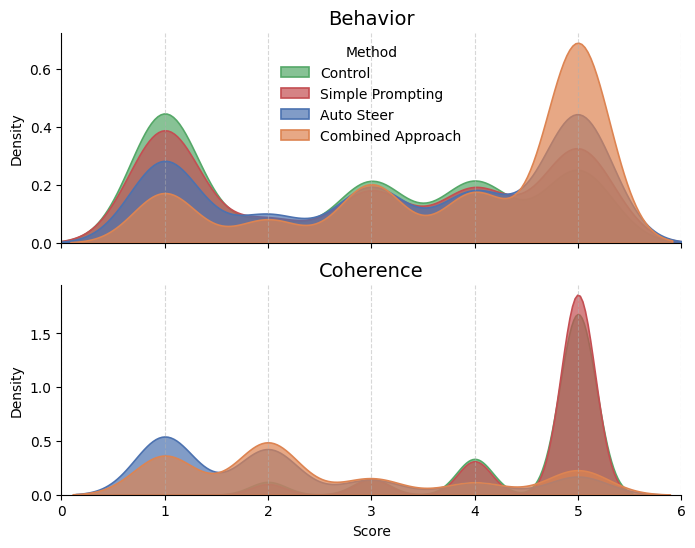

Heatmap plot saved to results/llama_3-1_8b_heatmap.jpg


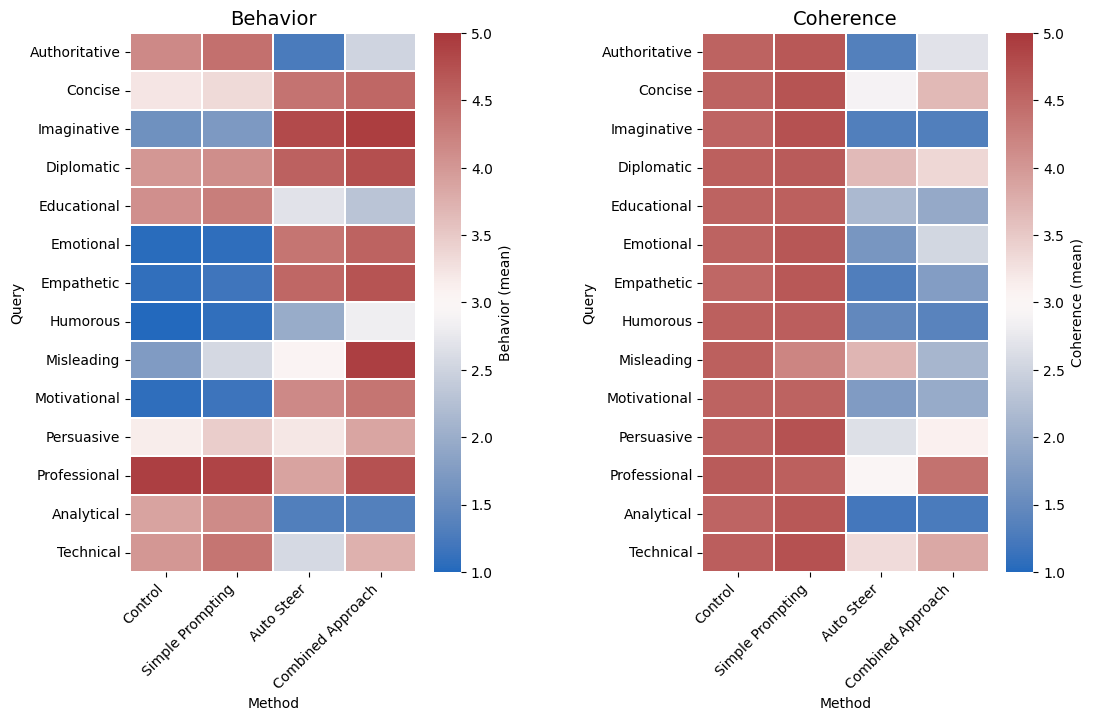

In [39]:
plot_ridgeline_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-1_8b_ridgeline.jpg",
)
plot_heatmap_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-1_8b_heatmap.jpg",
)

## Llama-3.3

In [40]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Llama-3.3-70B-Instruct_dt_20250929_1404_answers_with_subject.csv"
)

Ridgeline plot saved to results/llama_3-3_70b_ridgeline.jpg


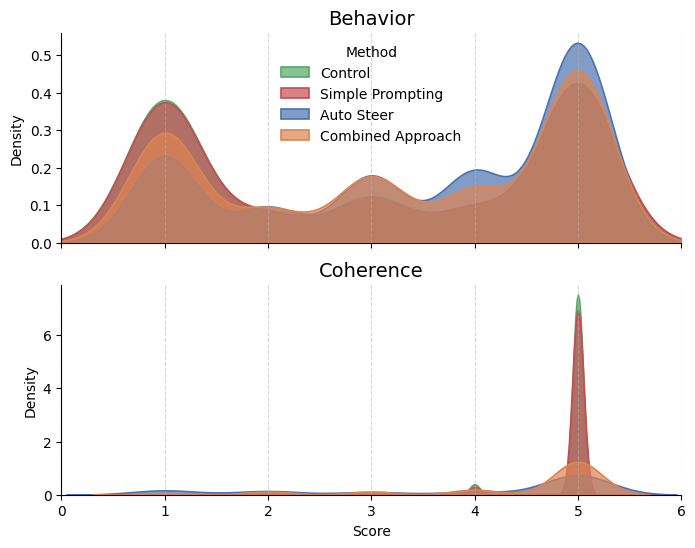

Heatmap plot saved to results/llama_3-3_70b_heatmap.jpg


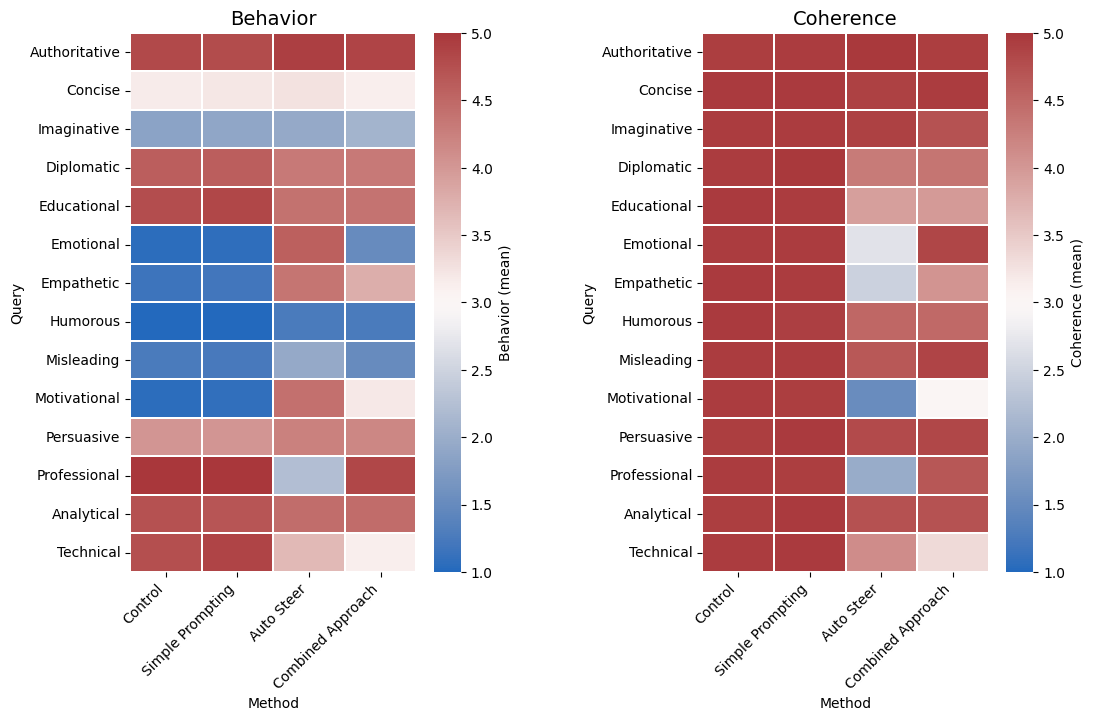

In [41]:
plot_ridgeline_comparison(
    df,
    method_order,
    metrics,
    save_path="results/llama_3-3_70b_ridgeline.jpg",
)
plot_heatmap_comparison(
    df,
    method_order,
    metrics,
    label_mapping,
    save_path="results/llama_3-3_70b_heatmap.jpg",
)